# Donut Geometry

In this case, we'll see that even the shape is simple, it still take a while.

In [1]:
import meep as mp
from matplotlib import pyplot as plt
import numpy as np
import time

In [2]:
cell = mp.Vector3(10, 10, 0)
pml_layers = [mp.PML(1.0)]
resolution = 10

In [3]:
def test_geom(position):
    r = np.sqrt(position.x**2 + position.y**2)
    if 1 <= r <= 2:
        return mp.Medium(epsilon=1.5)
    return mp.air

test_geom.do_averaging = True

geometry = []
geometry.append(mp.Block(center=mp.Vector3(),
                         size=cell,    # Set the GeometricObject has the same size as the cell
                         material=test_geom))

In [4]:
sources = [mp.Source(mp.ContinuousSource(frequency=0.15),
                     component=mp.Ez,
                     center=mp.Vector3(0,-3),
                     size=mp.Vector3(2,0,0))]

     block, center = (0,0,0)
          size (10,10,0)
          axes (1,0,0), (0,1,0), (0,0,1)


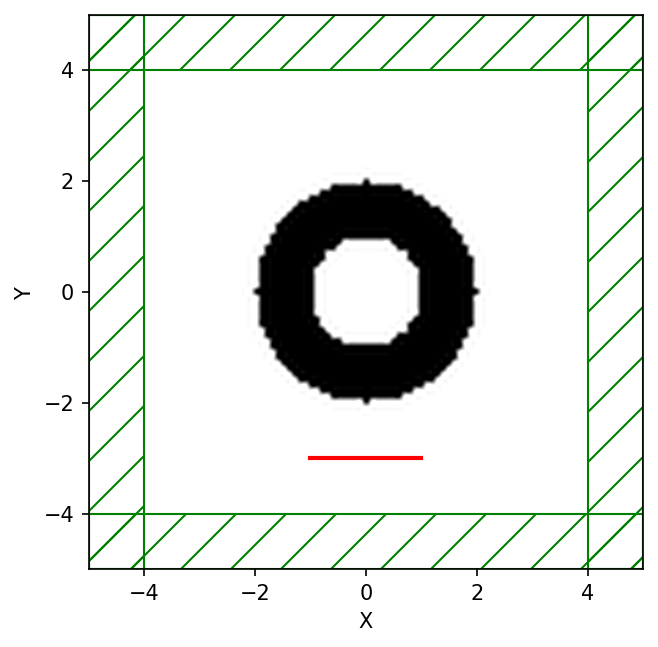

In [5]:
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry,
                    resolution=resolution,
                    sources=sources,
                    boundary_layers=pml_layers)

f = plt.figure(dpi=150)
sim.plot2D(ax=f.gca())
plt.show()

-----------
Initializing structure...
time for choose_chunkdivision = 0.000355959 s
Working in 2D dimensions.
Computational cell is 10 x 10 x 0 with resolution 10
     block, center = (0,0,0)
          size (10,10,0)
          axes (1,0,0), (0,1,0), (0,0,1)
subpixel-averaging is 32.0301% done, 40.6776 s remaining
subpixel-averaging is 48.0532% done, 39.3266 s remaining
subpixel-averaging is 64.0763% done, 17.6684 s remaining
subpixel-averaging is 80.0993% done, 6.8641 s remaining
subpixel-averaging is 32.0301% done, 38.8895 s remaining
subpixel-averaging is 48.0532% done, 41.07 s remaining
subpixel-averaging is 64.0763% done, 18.0554 s remaining
subpixel-averaging is 80.0993% done, 6.88941 s remaining
subpixel-averaging is 32.0301% done, 43.1374 s remaining
subpixel-averaging is 48.0532% done, 45.4281 s remaining
subpixel-averaging is 64.0763% done, 18.8596 s remaining
subpixel-averaging is 80.0993% done, 7.30623 s remaining
time for set_epsilon = 356.793 s
-----------
comsumed time: 3

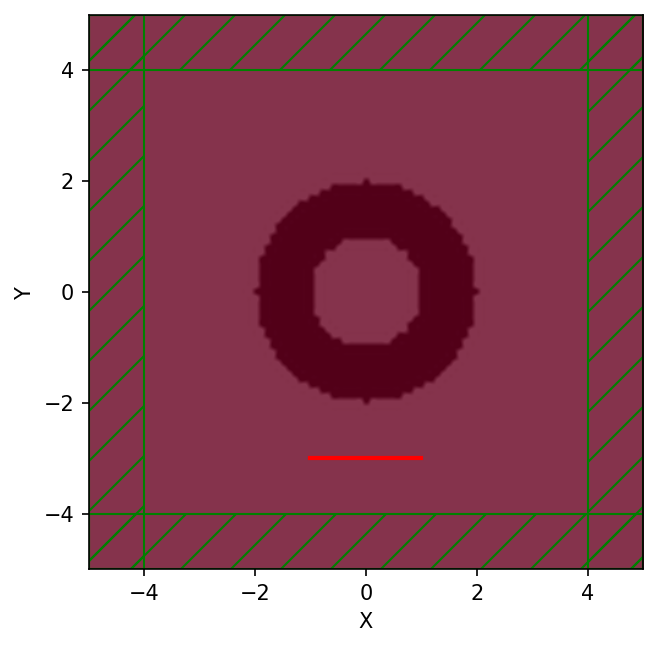

In [6]:
start = time.time()
sim.init_sim()
end = time.time()
print(f"comsumed time: {end - start} sec")

f = plt.figure(dpi=150)
sim.plot2D(fields=mp.Ez)
plt.show()